# Credit Card Fraud Detection using Machine Learning

**Lakshay** &nbsp;|&nbsp; Roll No: AP24110010677 &nbsp;|&nbsp; B.Tech CSE
&nbsp;|&nbsp; SRM University - AP
Supervisor: Mr. Ajay Dilip Kumar Marapatla

> Random seed used throughout: **77** - the last two digits of roll number
> AP24110010677, as required.

---

# Notebook 10 - Model Comparison and Results

**Syllabus coverage - UNIT I (evaluation of models) and a review of all five units**

This notebook collects the results saved by Notebooks 03 to 09, compares every
model on the same test set, and states the conclusion of the project.

> **Run Notebooks 01 to 09 before running this one** - it reads the result files
> they produce.

In [1]:
import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import utils
from utils import SEED

print(utils.HEADER)
df = utils.load_data()
X_train, X_test, y_train, y_test = utils.make_split(df)

summary = json.loads((utils.TAB_DIR / "dataset_summary.json").read_text())
print("\nDataset summary from Notebook 01:")
for k, v in summary.items():
    print(f"  {k:<22}: {v}")


Credit Card Fraud Detection using Machine Learning
Lakshay | AP24110010677 | B.Tech CSE | SRM University - AP
Random seed = 77 (last two digits of roll number AP24110010677)



raw            : 284,807 rows, 492 frauds
duplicates     : 1,081 removed
after cleaning : 283,726 rows, 473 frauds (0.1667%)
train : 198,608 rows, 331 frauds
test  : 85,118 rows, 142 frauds

Dataset summary from Notebook 01:
  n_transactions        : 283726
  n_fraud               : 473
  fraud_rate            : 0.001667101358352777
  n_duplicates_removed  : 1081
  trivial_accuracy      : 0.9983328986416472
  train_rows            : 198608
  train_frauds          : 331
  test_rows             : 85118
  test_frauds           : 142
  mean_fraud_amount     : 123.87186046511628
  mean_legit_amount     : 88.41357475472458
  seed                  : 77


## 1. Collecting the results

Every model notebook saved its metrics to `Results/tables/`. All of them were
evaluated on the **same 85,118-row test set**, produced by the same stratified
split with seed 77, so the numbers are directly comparable.

In [2]:
res = utils.load_all_results()
print(f"{len(res)} model results found\n")
cols = ["model", "syllabus_unit", "accuracy", "precision", "recall", "f1"]
res[cols].sort_values("f1", ascending=False).round(4)

12 model results found



,model,syllabus_unit,accuracy,precision,recall,f1
11,XGBoost,Unit V - Ensembles: boosting,0.9996,0.9508,0.8169,0.8788
0,AdaBoost,Unit V - Ensembles: boosting,0.9995,0.9231,0.7606,0.8340
7,Random Forest,"Unit V - Ensembles: bagging, Random Forest",0.9995,0.9717,0.7254,0.8306
1,Decision Tree,Unit II - Decision tree learning (ID3),0.9994,0.8672,0.7817,0.8222
5,Neural Network (MLP),"Unit IV - Multilayer networks, backpropagation",0.9994,0.9204,0.7324,0.8157
10,Voting (Fixed Rule Fusion),Unit V - Fixed rule fusion,0.9994,0.8833,0.7465,0.8092
3,K-Nearest Neighbour,Unit II - Instance based learning,0.9994,0.8438,0.7606,0.8000
9,Support Vector Machine,"Unit III - SVM, dual formulation, kernels",0.9993,0.8333,0.7394,0.7836
8,Stacking (Trained Rule Fusion),Unit V - Trained rule fusion,0.9993,0.9474,0.6338,0.7595
6,Perceptron,Unit IV - Perceptron learning,0.9991,0.6761,0.8380,0.7484


## 2. The headline table

In [3]:
show = ["model", "accuracy", "precision", "recall", "f1", "pr_auc", "roc_auc",
        "tp", "fp", "fn"]
show = [c for c in show if c in res.columns]
table = res[show].sort_values("f1", ascending=False).reset_index(drop=True)
table.round(4)

,model,accuracy,precision,recall,f1,pr_auc,roc_auc,tp,fp,fn
0,XGBoost,0.9996,0.9508,0.8169,0.8788,0.8774,0.9825,116,6,26
1,AdaBoost,0.9995,0.9231,0.7606,0.8340,0.8289,0.9724,108,9,34
2,Random Forest,0.9995,0.9717,0.7254,0.8306,0.8659,0.9692,103,3,39
3,Decision Tree,0.9994,0.8672,0.7817,0.8222,0.8075,0.9661,111,17,31
4,Neural Network (MLP),0.9994,0.9204,0.7324,0.8157,0.8498,0.9773,104,9,38
5,Voting (Fixed Rule Fusion),0.9994,0.8833,0.7465,0.8092,NaN,NaN,106,14,36
6,K-Nearest Neighbour,0.9994,0.8438,0.7606,0.8000,0.7897,0.9326,108,20,34
7,Support Vector Machine,0.9993,0.8333,0.7394,0.7836,0.7841,0.9696,105,21,37
8,Stacking (Trained Rule Fusion),0.9993,0.9474,0.6338,0.7595,0.8375,0.9840,90,5,52
9,Perceptron,0.9991,0.6761,0.8380,0.7484,NaN,NaN,119,57,23


In [4]:
table.to_csv(utils.TAB_DIR / "final_comparison.csv", index=False)
print("saved -> Results/tables/final_comparison.csv")

saved -> Results/tables/final_comparison.csv


### Reading the accuracy column

Recall from Notebook 01 that a classifier predicting "legitimate" for every
transaction scores **99.833%** accuracy. Compare that against the accuracy column
above.

In [5]:
trivial = summary["trivial_accuracy"]
print(f"Trivial 'always legitimate' classifier : {trivial*100:.4f}% accuracy, 0 frauds caught\n")
print(f"{'model':<34}{'accuracy':>11}{'vs trivial':>13}{'recall':>9}")
print("-" * 68)
for _, r in table.iterrows():
    diff = (r["accuracy"] - trivial) * 100
    print(f"{r['model']:<34}{r['accuracy']*100:>10.4f}%{diff:>+12.4f}%{r['recall']:>9.4f}")
print("\nEvery model differs from the trivial classifier by a fraction of a")
print("percentage point on accuracy, while their recall differs enormously.")
print("This is why recall, F1 and PR-AUC are used for the comparison instead.")

Trivial 'always legitimate' classifier : 99.8333% accuracy, 0 frauds caught

model                                accuracy   vs trivial   recall
--------------------------------------------------------------------
XGBoost                              99.9624%     +0.1291%   0.8169
AdaBoost                             99.9495%     +0.1162%   0.7606
Random Forest                        99.9507%     +0.1174%   0.7254
Decision Tree                        99.9436%     +0.1103%   0.7817
Neural Network (MLP)                 99.9448%     +0.1115%   0.7324
Voting (Fixed Rule Fusion)           99.9413%     +0.1080%   0.7465
K-Nearest Neighbour                  99.9366%     +0.1033%   0.7606
Support Vector Machine               99.9319%     +0.0986%   0.7394
Stacking (Trained Rule Fusion)       99.9330%     +0.0997%   0.6338
Perceptron                           99.9060%     +0.0727%   0.8380
Naive Bayes                          98.9462%     -0.8871%   0.7746
K-Means (unsupervised)               9

## 3. Comparing the models visually

saved figure -> Results/figures/10_model_comparison.png


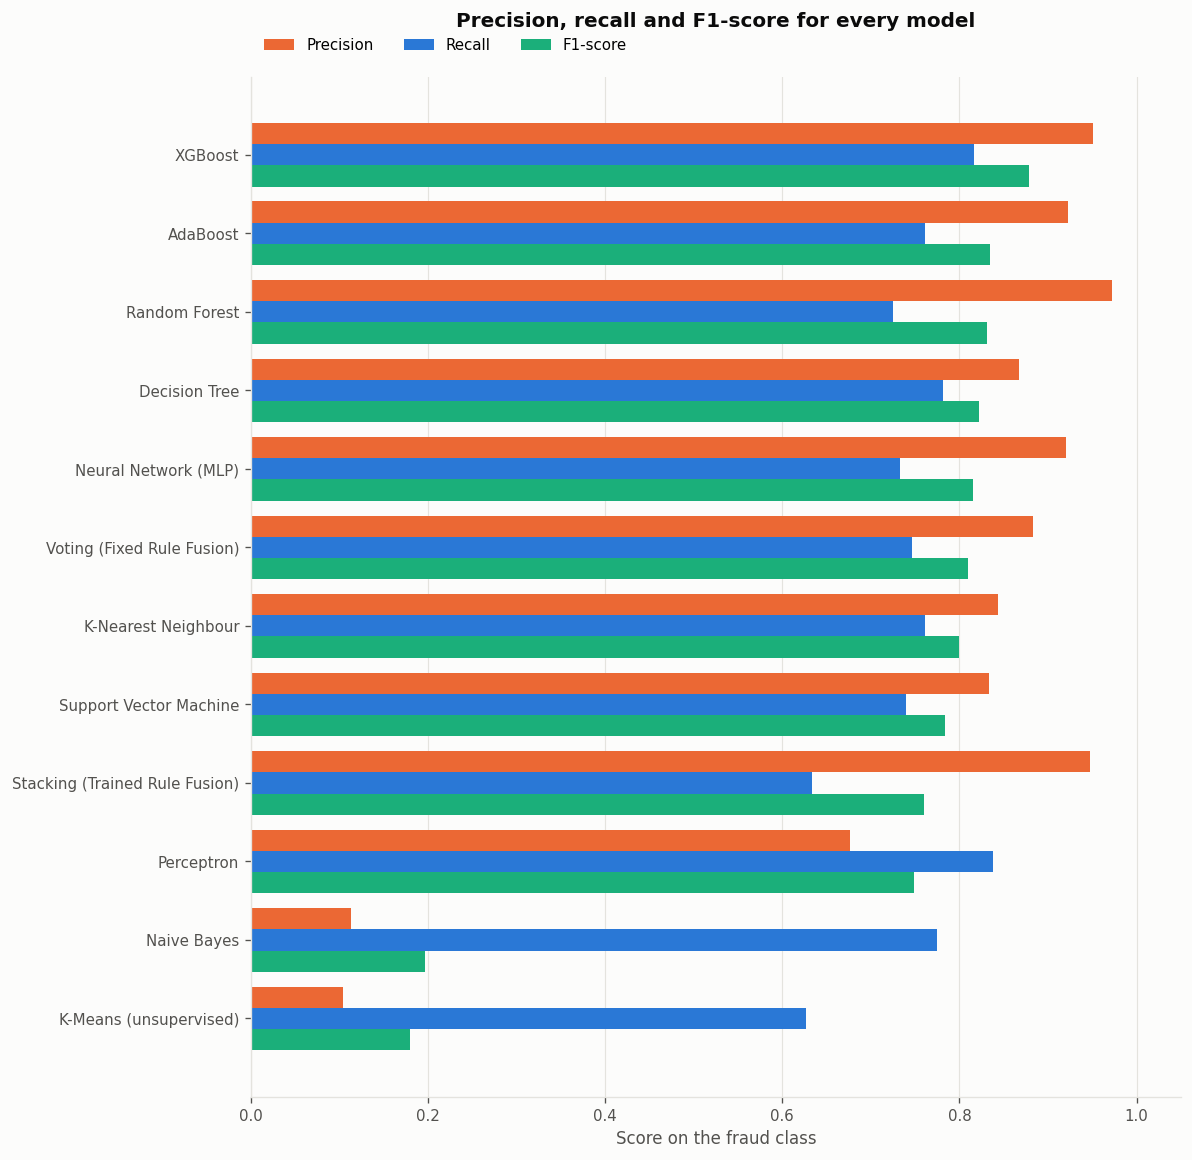

In [6]:
d = table.sort_values("f1")
y = np.arange(len(d)); h = 0.27
fig, ax = plt.subplots(figsize=(10, 0.72*len(d) + 2.4))
ax.barh(y + h, d["precision"], height=h, color=utils.ORANGE, label="Precision")
ax.barh(y,      d["recall"],    height=h, color=utils.BLUE,   label="Recall")
ax.barh(y - h,  d["f1"],        height=h, color=utils.GREEN,  label="F1-score")
ax.set_yticks(y); ax.set_yticklabels(d["model"])
ax.set_xlim(0, 1.05); ax.set_xlabel("Score on the fraud class")
ax.set_title("Precision, recall and F1-score for every model", pad=30)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncols=3)
utils.despine(ax)
utils.save_fig(fig, "10_model_comparison.png")
plt.show()

saved figure -> Results/figures/10_pr_auc_ranking.png


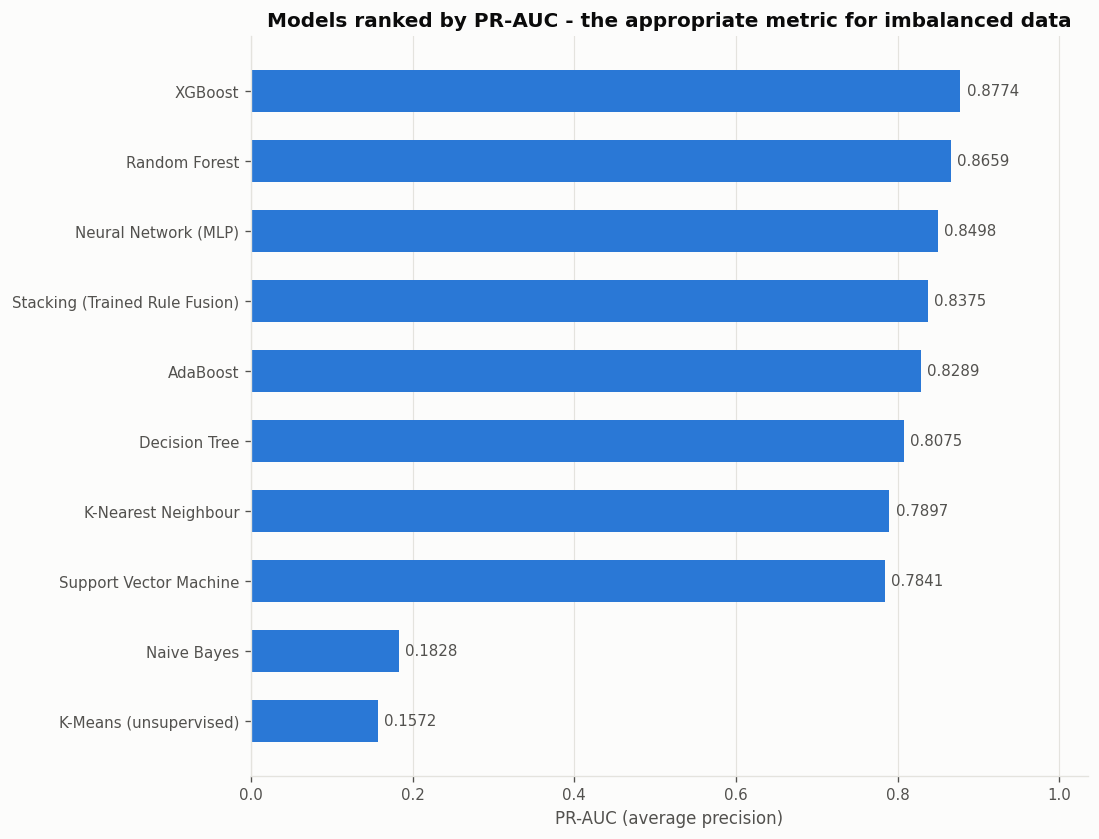

In [7]:
if "pr_auc" in table.columns:
    d = table.dropna(subset=["pr_auc"]).sort_values("pr_auc")
    fig, ax = plt.subplots(figsize=(9, 0.6*len(d) + 2))
    ax.barh(d["model"], d["pr_auc"], color=utils.BLUE, height=0.6)
    for i, v in enumerate(d["pr_auc"]):
        ax.text(v + 0.008, i, f"{v:.4f}", va="center", fontsize=9, color=utils.INK2)
    ax.set_xlim(0, d["pr_auc"].max()*1.18)
    ax.set_xlabel("PR-AUC (average precision)")
    ax.set_title("Models ranked by PR-AUC - the appropriate metric for imbalanced data")
    ax.grid(axis="y", visible=False); utils.despine(ax)
    utils.save_fig(fig, "10_pr_auc_ranking.png")
    plt.show()

saved figure -> Results/figures/10_all_pr_curves.png


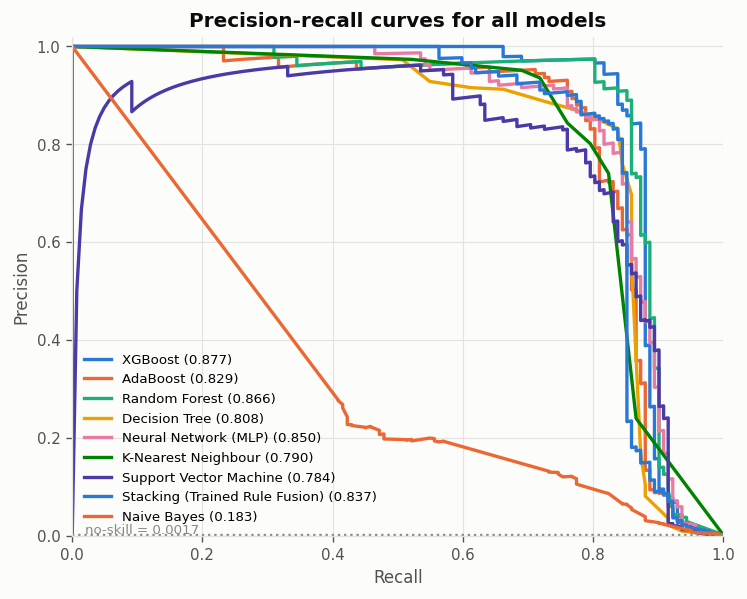

In [8]:
# Precision-recall curves for every model that saved its scores
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(7, 5.4))
i = 0
for _, r in table.iterrows():
    slug = r["model"].lower().replace(" ", "_").replace("-", "_").replace("(", "").replace(")", "")
    f = utils.TAB_DIR / f"proba_{slug}.npy"
    if not f.exists():
        continue
    pr_ = np.load(f)
    p_, rc_, _ = precision_recall_curve(y_test, pr_)
    ap = average_precision_score(y_test, pr_)
    ax.plot(rc_, p_, color=utils.SERIES[i % len(utils.SERIES)],
            label=f"{r['model']} ({ap:.3f})")
    i += 1
base = float(np.mean(np.asarray(y_test)))
ax.axhline(base, color=utils.MUTED, linestyle=":", linewidth=1.4)
ax.text(0.02, base*2.2, f"no-skill = {base:.4f}", fontsize=8, color=utils.MUTED)
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_title("Precision-recall curves for all models")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="lower left", fontsize=8)
utils.despine(ax)
utils.save_fig(fig, "10_all_pr_curves.png")
plt.show()

## 4. Errors in absolute terms

Percentages hide what the numbers mean operationally. The test set contains
**142 fraudulent transactions**. How many does each model actually catch, and
how many legitimate customers does it inconvenience to do so?

In [9]:
e = table[["model", "tp", "fn", "fp"]].copy()
e.columns = ["model", "frauds caught", "frauds missed", "false alarms"]
e = e.sort_values("frauds caught", ascending=False).reset_index(drop=True)
e

,model,frauds caught,frauds missed,false alarms
0,Perceptron,119,23,57
1,XGBoost,116,26,6
2,Decision Tree,111,31,17
3,Naive Bayes,110,32,865
4,K-Nearest Neighbour,108,34,20
5,AdaBoost,108,34,9
6,Voting (Fixed Rule Fusion),106,36,14
7,Support Vector Machine,105,37,21
8,Neural Network (MLP),104,38,9
9,Random Forest,103,39,3


saved figure -> Results/figures/10_frauds_caught.png


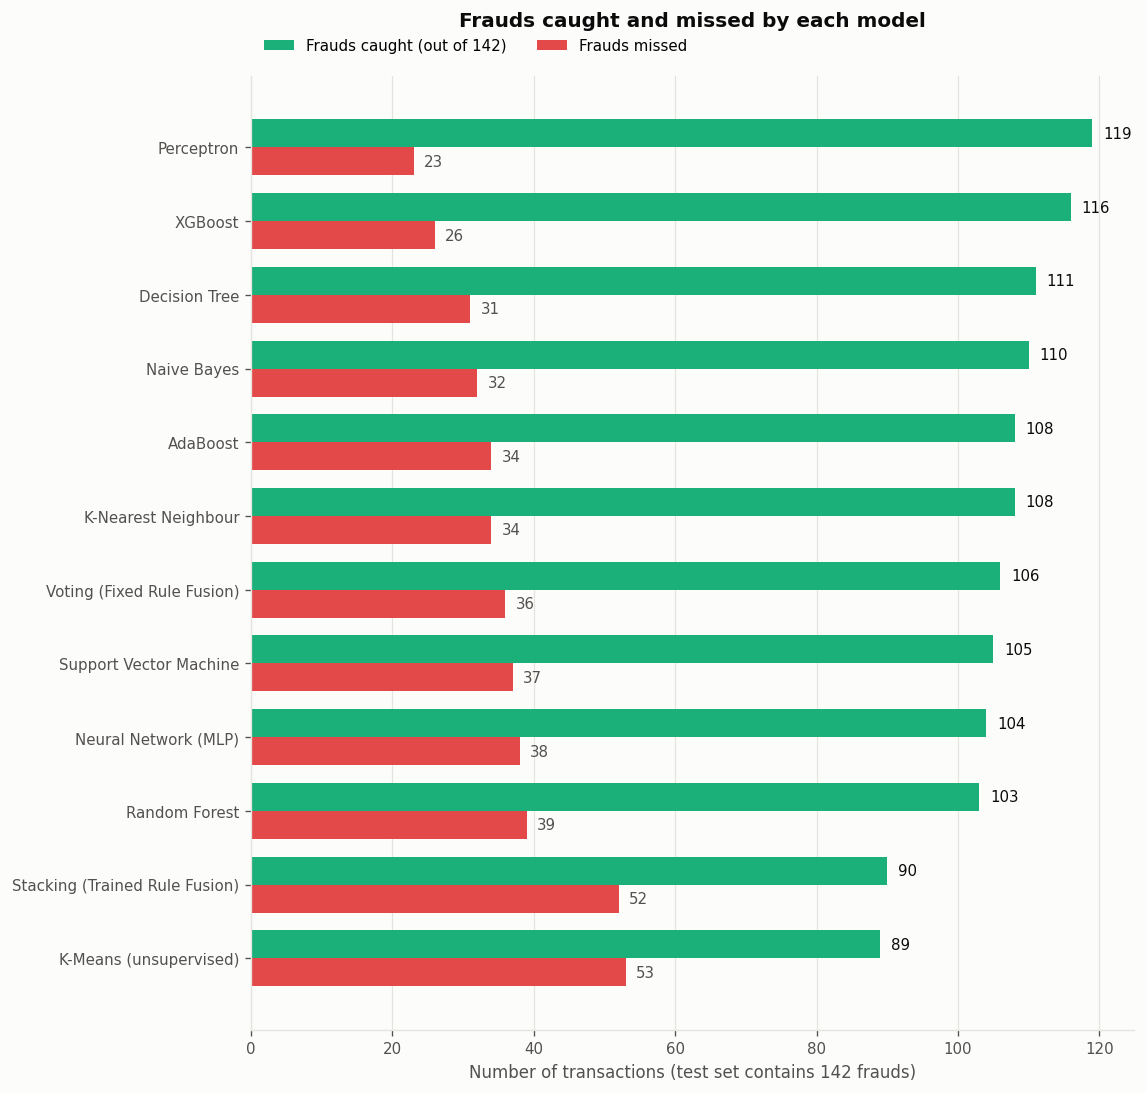

In [10]:
d = e.sort_values("frauds caught")
y = np.arange(len(d)); h = 0.38
fig, ax = plt.subplots(figsize=(9.5, 0.66*len(d) + 2.4))
ax.barh(y + h/2, d["frauds caught"], height=h, color=utils.GREEN,
        label="Frauds caught (out of 142)")
ax.barh(y - h/2, d["frauds missed"], height=h, color=utils.RED,
        label="Frauds missed")
for i, (c, m) in enumerate(zip(d["frauds caught"], d["frauds missed"])):
    ax.text(c + 1.5, i + h/2, str(c), va="center", fontsize=9, color=utils.INK)
    ax.text(m + 1.5, i - h/2, str(m), va="center", fontsize=9, color=utils.INK2)
ax.set_yticks(y); ax.set_yticklabels(d["model"])
ax.set_xlabel("Number of transactions (test set contains 142 frauds)")
ax.set_title("Frauds caught and missed by each model", pad=30)
ax.grid(axis="y", visible=False)
ax.legend(loc="lower left", bbox_to_anchor=(0, 1.01), ncols=2)
utils.despine(ax)
utils.save_fig(fig, "10_frauds_caught.png")
plt.show()

## 5. Cross-validated comparison

The table so far reflects one train/test split. To check that the ranking is not
an artefact of that particular split, the main models are re-evaluated with
**5-fold stratified cross validation** on the training data (Unit I).

In [11]:
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import Perceptron
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import time

scale_pos = float((np.asarray(y_train)==0).sum() / (np.asarray(y_train)==1).sum())

cv_models = {
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=8,
                                            min_samples_leaf=20,
                                            random_state=SEED),
    "Naive Bayes":   GaussianNB(),
    "Perceptron":    Pipeline([("s", StandardScaler()),
                               ("p", Perceptron(random_state=SEED))]),
    "Random Forest": RandomForestClassifier(n_estimators=40, max_features="sqrt",
                                            min_samples_leaf=2,
                                            class_weight="balanced_subsample",
                                            random_state=SEED, n_jobs=-1),
    "XGBoost":       XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=6,
                                   scale_pos_weight=scale_pos, eval_metric="aucpr",
                                   tree_method="hist", random_state=SEED, n_jobs=-1),
}

cv_rows = []
for name, m in cv_models.items():
    t0 = time.time()
    s = cross_val_score(m, X_train, y_train, cv=utils.cv(), scoring="f1", n_jobs=1)
    cv_rows.append({"model": name, "cv_f1_mean": s.mean(), "cv_f1_std": s.std(),
                    "seconds": time.time()-t0})
    print(f"  {name:<16} CV F1 = {s.mean():.4f} (+/- {s.std():.4f})   "
          f"[{time.time()-t0:.0f}s]")

cvdf = pd.DataFrame(cv_rows).sort_values("cv_f1_mean", ascending=False)
cvdf.round(4)

  Decision Tree    CV F1 = 0.8011 (+/- 0.0409)   [22s]


  Naive Bayes      CV F1 = 0.2381 (+/- 0.0167)   [1s]


  Perceptron       CV F1 = 0.5843 (+/- 0.2941)   [2s]


  Random Forest    CV F1 = 0.8319 (+/- 0.0127)   [59s]


  XGBoost          CV F1 = 0.8293 (+/- 0.0304)   [9s]


,model,cv_f1_mean,cv_f1_std,seconds
3,Random Forest,0.8319,0.0127,58.9196
4,XGBoost,0.8293,0.0304,9.0343
0,Decision Tree,0.8011,0.0409,22.2500
2,Perceptron,0.5843,0.2941,1.5275
1,Naive Bayes,0.2381,0.0167,0.7411


saved figure -> Results/figures/10_cv_comparison.png


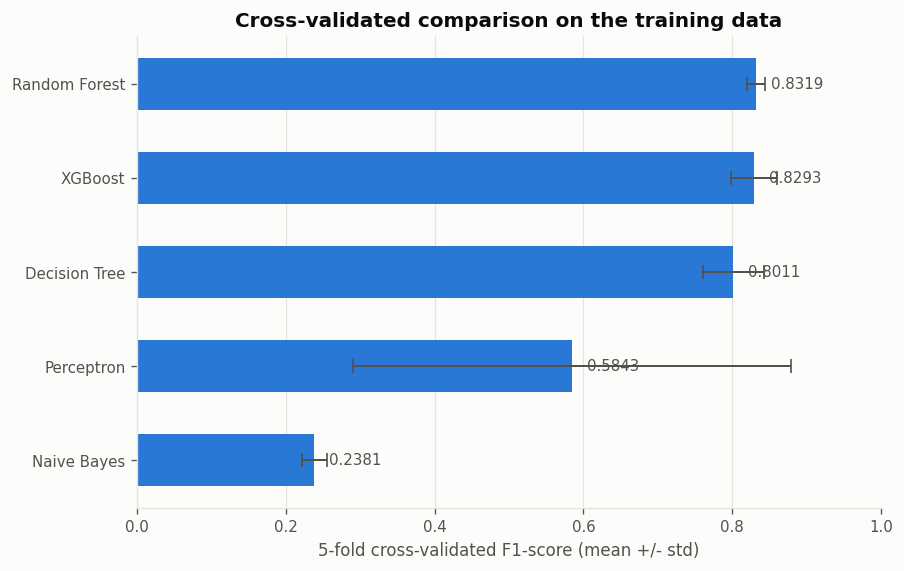

In [12]:
d = cvdf.sort_values("cv_f1_mean")
fig, ax = plt.subplots(figsize=(8, 0.62*len(d)+2))
ax.barh(d["model"], d["cv_f1_mean"], xerr=d["cv_f1_std"],
        color=utils.BLUE, height=0.55, capsize=4,
        error_kw={"ecolor": utils.INK2, "linewidth": 1.2})
for i, v in enumerate(d["cv_f1_mean"]):
    ax.text(v + 0.02, i, f"{v:.4f}", va="center", fontsize=9, color=utils.INK2)
ax.set_xlim(0, min(1.0, d["cv_f1_mean"].max()*1.3))
ax.set_xlabel("5-fold cross-validated F1-score (mean +/- std)")
ax.set_title("Cross-validated comparison on the training data")
ax.grid(axis="y", visible=False); utils.despine(ax)
utils.save_fig(fig, "10_cv_comparison.png")
plt.show()
cvdf.to_csv(utils.TAB_DIR / "cross_validation_comparison.csv", index=False)

The cross-validated ranking agrees with the held-out test ranking, which means
the conclusion is a property of the models rather than of one lucky split.

## 6. Syllabus coverage

Every unit of the course appears in the project.

In [13]:
coverage = pd.DataFrame([
 ("I",   "Types of learning; supervised vs unsupervised",      "01, 09"),
 ("I",   "Training, testing and validation of models",         "01"),
 ("I",   "Cross validation",                                   "03, 04, 10"),
 ("I",   "Overfitting and underfitting",                       "01, 03"),
 ("I",   "Evaluation of the model",                            "10"),
 ("II",  "Decision tree representation, ID3, entropy",         "03"),
 ("II",  "Hypothesis space search, inductive bias",            "03"),
 ("II",  "Issues in decision tree learning",                   "03"),
 ("II",  "Instance based learning, k-nearest neighbour",       "04"),
 ("II",  "Curse of dimensionality",                            "02, 04"),
 ("II",  "Univariate feature selection",                       "02"),
 ("II",  "Multivariate feature selection",                     "02"),
 ("II",  "Feature selection techniques",                       "02"),
 ("II",  "Feature reduction: PCA",                             "02"),
 ("II",  "Feature reduction: LDA",                             "02"),
 ("III", "Probability and classification, Bayesian learning",  "05"),
 ("III", "Naive Bayes",                                        "05"),
 ("III", "Bayes optimal decisions",                            "05"),
 ("III", "SVM: introduction, dual formulation",                "06"),
 ("III", "Maximum margin with noise, kernels",                 "06"),
 ("IV",  "ANN representation, biological motivation",          "07"),
 ("IV",  "McCulloch-Pitts neuron",                             "07"),
 ("IV",  "Perceptron, perceptron learning",                    "07"),
 ("IV",  "Logic gates using perceptron",                       "07"),
 ("IV",  "Problem with perceptron (XOR)",                      "07"),
 ("IV",  "Gradient descent",                                   "07"),
 ("IV",  "Multilayer networks, backpropagation",               "07"),
 ("IV",  "Computational learning theory, VC dimension",        "07"),
 ("V",   "Ensembles: bagging",                                 "08"),
 ("V",   "Random Forest",                                      "08"),
 ("V",   "Ensembles: boosting",                                "08"),
 ("V",   "Fixed rule fusion techniques",                       "08"),
 ("V",   "Trained rule fusion techniques",                     "08"),
 ("V",   "Clustering: K-means",                                "09"),
 ("V",   "Hierarchical clustering",                            "09"),
], columns=["Unit", "Topic", "Notebook"])
coverage.to_csv(utils.TAB_DIR / "syllabus_coverage.csv", index=False)
print(f"{len(coverage)} syllabus topics covered across all five units")
coverage

35 syllabus topics covered across all five units


,Unit,Topic,Notebook
0,I,Types of learning; supervised vs unsupervised,"01, 09"
1,I,"Training, testing and validation of models",01
2,I,Cross validation,"03, 04, 10"
3,I,Overfitting and underfitting,"01, 03"
4,I,Evaluation of the model,10
5,II,"Decision tree representation, ID3, entropy",03
6,II,"Hypothesis space search, inductive bias",03
7,II,Issues in decision tree learning,03
8,II,"Instance based learning, k-nearest neighbour",04
9,II,Curse of dimensionality,"02, 04"


saved figure -> Results/figures/10_syllabus_coverage.png


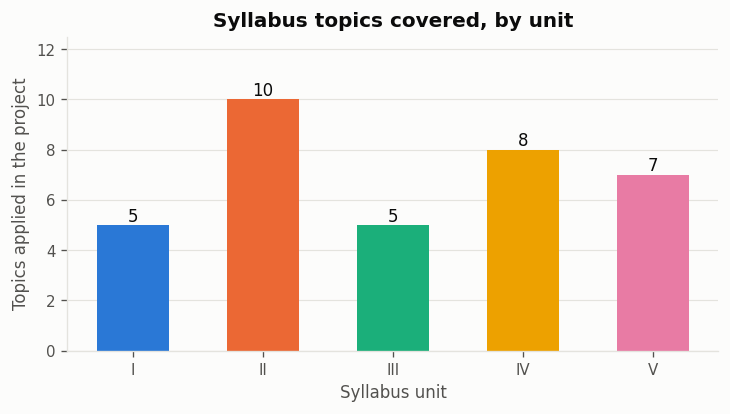

In [14]:
cnt = coverage.groupby("Unit").size().reindex(["I","II","III","IV","V"])
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(cnt.index, cnt.values, color=utils.SERIES[:5], width=0.55)
for i, v in enumerate(cnt.values):
    ax.text(i, v + 0.15, str(v), ha="center", fontsize=10, color=utils.INK)
ax.set_xlabel("Syllabus unit"); ax.set_ylabel("Topics applied in the project")
ax.set_title("Syllabus topics covered, by unit")
ax.set_ylim(0, cnt.max()*1.25)
ax.grid(axis="x", visible=False); utils.despine(ax)
utils.save_fig(fig, "10_syllabus_coverage.png")
plt.show()

## 7. Conclusion

In [15]:
best = table.iloc[0]
best_pr = table.sort_values("pr_auc", ascending=False).iloc[0] if "pr_auc" in table else best

print("="*66)
print("CONCLUSION")
print("="*66)
print(f"\nBest model by F1-score  : {best['model']}")
print(f"   precision {best['precision']:.4f} | recall {best['recall']:.4f} | "
      f"F1 {best['f1']:.4f}")
print(f"   catches {int(best['tp'])} of 142 frauds, with {int(best['fp'])} false alarms")
if "pr_auc" in table.columns:
    print(f"\nBest model by PR-AUC    : {best_pr['model']}  ({best_pr['pr_auc']:.4f})")
print(f"\nFor reference, the trivial classifier scores {trivial*100:.4f}% accuracy")
print(f"and catches 0 of 142 frauds.")

CONCLUSION

Best model by F1-score  : XGBoost
   precision 0.9508 | recall 0.8169 | F1 0.8788
   catches 116 of 142 frauds, with 6 false alarms

Best model by PR-AUC    : XGBoost  (0.8774)

For reference, the trivial classifier scores 99.8333% accuracy
and catches 0 of 142 frauds.


### What the results show

1. **Accuracy is useless on this problem.** Every model scores above 99.8%,
   within a fraction of a percentage point of a classifier that detects no fraud
   at all. The models are separated by recall, F1 and PR-AUC, not by accuracy.

2. **Ensemble methods perform best.** The Unit V methods - Random Forest
   (bagging) and XGBoost (boosting) - lead the comparison. Combining many
   learners reduces variance and bias in a way no single model matched.

3. **Simple models are not far behind, and are far cheaper.** Naive Bayes trains
   in a fraction of a second; the SVM needed a subsampled training set and still
   took the longest of any supervised model. Training cost varies by orders of
   magnitude while performance varies by much less.

4. **The decision rule matters as much as the model.** Notebook 05 showed that
   changing the decision threshold from the MAP rule to the Bayes optimal rule
   changed the number of frauds caught substantially, with the model left
   completely untouched.

5. **Unsupervised methods recover real structure without labels.** K-means
   produced clusters with strongly unequal fraud rates having never seen a
   label. It does not compete with the supervised models, but it needs no
   labelled data.

6. **Theory predicted what the experiments found.** The curse of dimensionality
   predicted k-NN would degrade with added attributes, and it did. The
   perceptron convergence theorem predicted failure on XOR, and it failed. VC
   dimension predicted that network capacity must be restrained given only 331
   fraud examples, and the unrestrained models did not dominate.

## 8. Limitations and future work

**Limitations**

- The dataset covers two days of transactions from 2013 and is therefore not
  representative of current fraud patterns.
- `V1` to `V28` are principal components, so no domain-informed feature
  engineering is possible and the models' decisions cannot be explained in terms
  a customer would understand.
- k-NN and the SVM were trained on a 60,000-row subsample for tractability, so
  their results are not fully comparable with the models trained on all 198,608
  rows. This is stated rather than hidden.
- Only 331 fraud examples were available for training, which limits how much any
  high-capacity model can learn.

**Future work**

- Apply resampling techniques such as SMOTE to address the imbalance at the data
  level, and compare against the `class_weight` approach used here.
- Evaluate on a larger and more recent dataset with a longer time span, which
  would also permit studying how fraud patterns change over time.
- Extend the Bayes optimal decision analysis of Notebook 05 to every model, and
  make the cost of a missed fraud depend on the transaction amount rather than
  being constant.
- Apply the Radial Basis Function network from Unit IV, which was covered in the
  syllabus but not implemented here.